In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Cell 4: Đọc dữ liệu
df = pd.read_csv('steam.csv')

print("Số game:", df.shape[0])
print("Các cột:", df.columns.tolist())

# Xem nhanh 5 game đầu
df

Số game: 27075
Các cột: ['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price']


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27070,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,windows,0,Single-player;Steam Achievements,Adventure;Casual;Indie,Adventure;Indie;Casual,7,3,0,0,0,0-20000,2.09
27071,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,windows,0,Single-player,Action;Adventure;Indie,Action;Indie;Adventure,0,8,1,0,0,0-20000,1.69
27072,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,windows,0,Single-player;Multi-player;Co-op;Shared/Split ...,Action;Casual;Indie,Action;Indie;Casual,24,0,1,0,0,0-20000,3.99
27073,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,2,0,0,0,0-20000,5.19


In [4]:
# Chuyển owners thành số trung bình
def owners_to_number(x):
    if '-' in str(x):
        low, high = str(x).split('-')
        return (int(low.replace(',', '')) + int(high.replace(',', ''))) // 2
    return 0

df['owners_num'] = df['owners'].apply(owners_to_number)

# Tính tỷ lệ đánh giá tích cực
df['positive_ratio'] = df['positive_ratings'] / (df['positive_ratings'] + df['negative_ratings'] + 1e-6)

# Fill missing values đơn giản
df.fillna({
    'price': 0,
    'positive_ratio': 0.5,
    'log_playtime': 0,
    'achievements': 0
}, inplace=True)

# Drop các hàng thiếu genres hoặc name (rất ít)
df.dropna(subset=['name', 'genres'], inplace=True)

print("Sau làm sạch:", df.shape)

Sau làm sạch: (27075, 20)


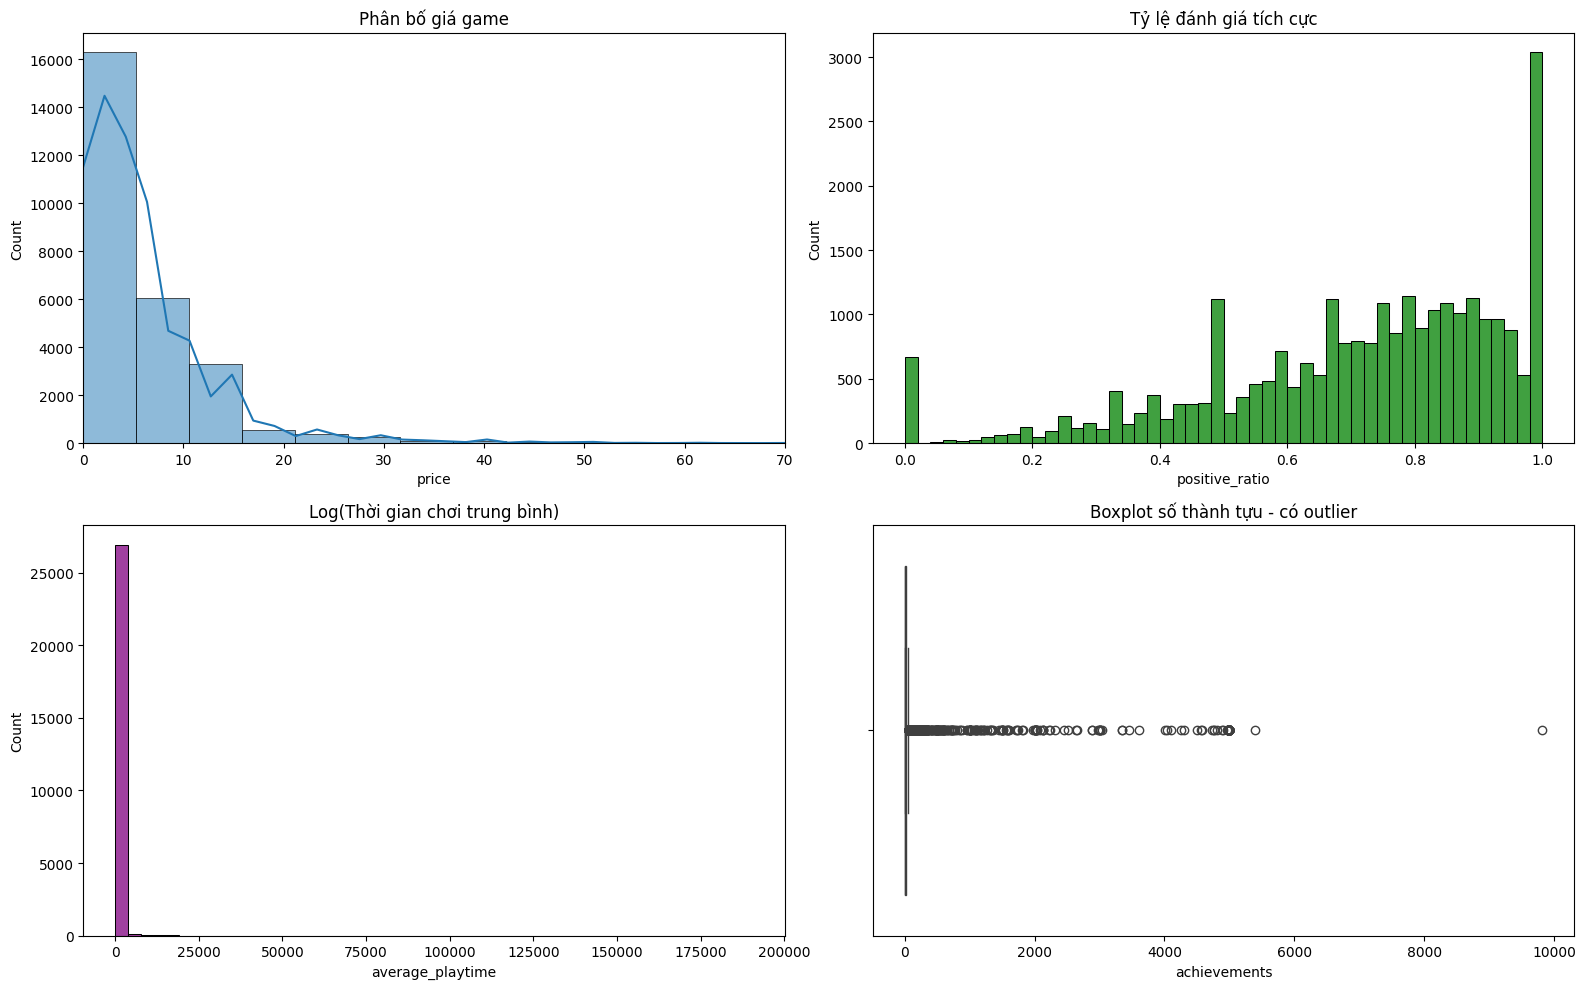

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Giá
sns.histplot(df['price'], bins=80, ax=axes[0,0], kde=True)
axes[0,0].set_title('Phân bố giá game')
axes[0,0].set_xlim(0, 70)

# Tỷ lệ positive
sns.histplot(df['positive_ratio'], bins=50, ax=axes[0,1], color='green')
axes[0,1].set_title('Tỷ lệ đánh giá tích cực')

# Thời gian chơi (log)
sns.histplot(df['average_playtime'], bins=50, ax=axes[1,0], color='purple')
axes[1,0].set_title('Log(Thời gian chơi trung bình)')

# Số thành tựu
sns.boxplot(x=df['achievements'], ax=axes[1,1])
axes[1,1].set_title('Boxplot số thành tựu - có outlier')

plt.tight_layout()
plt.show()

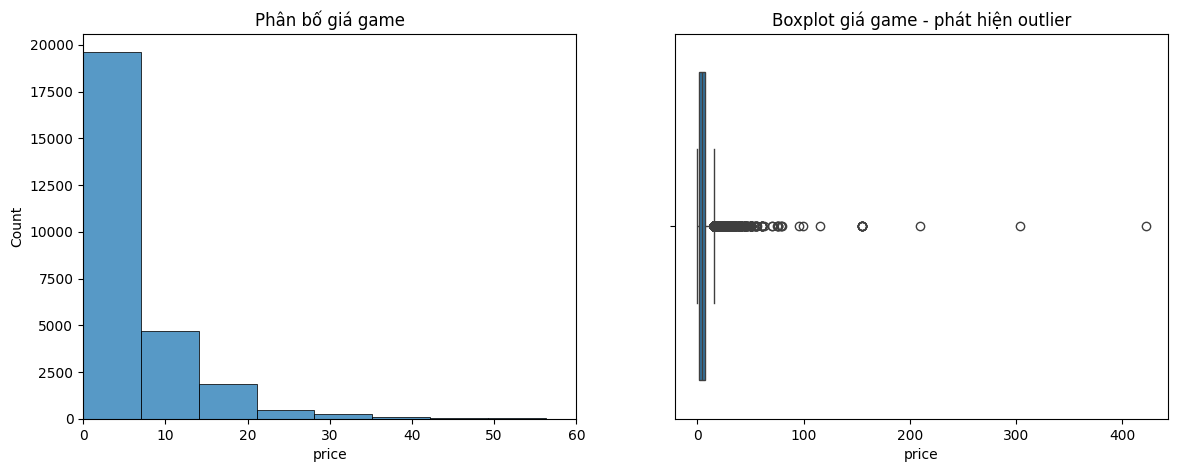

In [6]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['price'], bins=60)
plt.title('Phân bố giá game')
plt.xlim(0, 60)

plt.subplot(1,2,2)
sns.boxplot(x=df['price'])
plt.title('Boxplot giá game - phát hiện outlier')
plt.show()


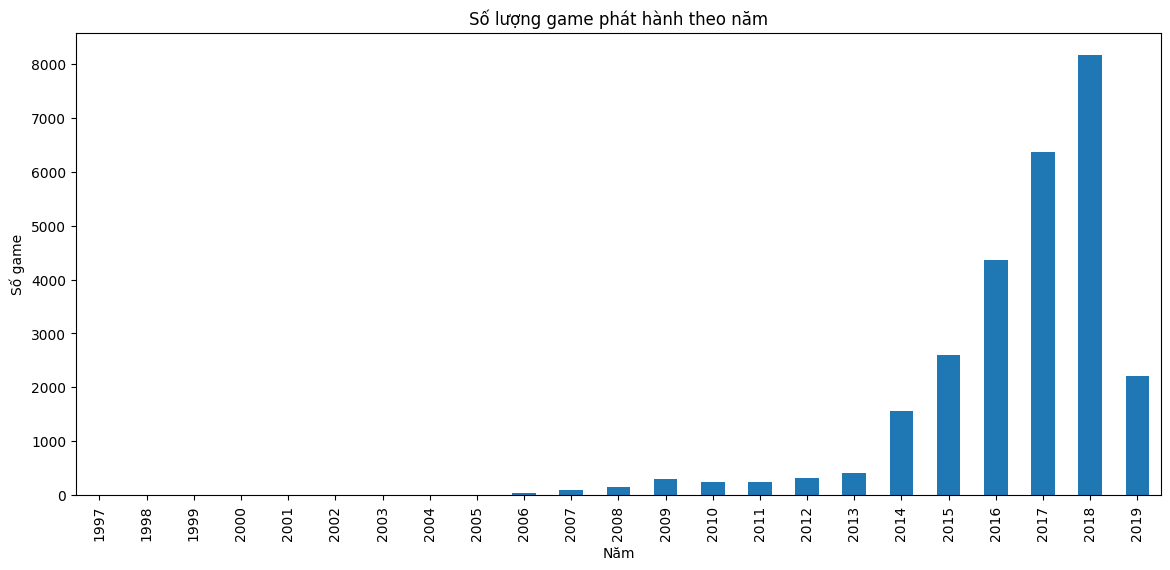

In [7]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year


plt.figure(figsize=(14,6))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title('Số lượng game phát hành theo năm')
plt.xlabel('Năm')
plt.ylabel('Số game')
plt.show()

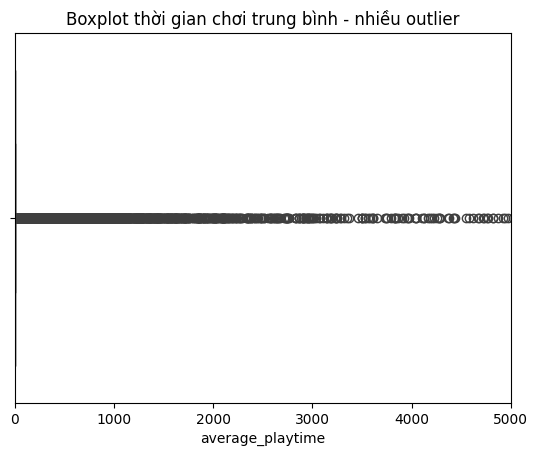

In [8]:
sns.boxplot(x=df['average_playtime'])
plt.title('Boxplot thời gian chơi trung bình - nhiều outlier')
plt.xlim(0, 5000)
plt.show()

In [9]:
high_price = df[df['price'] > 50].sort_values('price', ascending=False).head(10)
print("Top 10 game giá cao nhất (>50$):")
display(high_price[['name', 'price', 'genres', 'positive_ratio']])

long_play = df[df['average_playtime'] > 2000].sort_values('average_playtime', ascending=False).head(10)
print("\nTop 10 game chơi lâu nhất (>2000 giờ trung bình):")
display(long_play[['name', 'average_playtime', 'positive_ratio', 'price']])

Top 10 game giá cao nhất (>50$):


,name,price,genres,positive_ratio
21105,ADR-Labelling Game,421.99,Simulation,0.999999
13062,GameMaker Studio 2 UWP,303.99,Animation & Modeling;Design & Illustration;Edu...,0.999999
10034,Houdini Indie,209.99,Animation & Modeling;Design & Illustration;Gam...,1.000000
7992,3DF Zephyr Lite Steam Edition,154.99,Animation & Modeling;Design & Illustration;Vid...,0.937500
17126,Tactics 2: War,154.99,Action;Simulation;Strategy,0.333333
13063,GameMaker Studio 2 Mobile,154.99,Animation & Modeling;Design & Illustration;Edu...,0.650000
14917,CrisisActionVR,154.99,Violent;Gore;Action;Adventure;Indie;Massively ...,0.583333
25568,Bible Test,154.99,Adventure;Casual;Indie;Simulation,0.800000
10624,Tactics: Bludgeons Blessing,154.99,Action;Simulation;Strategy,0.000000
10910,Silhouette,154.99,Adventure;Indie;Early Access,0.764706



Top 10 game chơi lâu nhất (>2000 giờ trung bình):


,name,average_playtime,positive_ratio,price
9201,The Abbey of Crime Extensum,190625,0.869048,0.00
1478,The Banner Saga: Factions,95245,0.738003,0.00
6014,The Secret of Tremendous Corporation,95242,0.813433,0.00
8969,PRICE,63481,0.947416,0.00
3930,Boundless,55204,0.703478,32.99
3969,Shroud of the Avatar: Forsaken Virtues,54618,0.511527,0.00
2435,X-Plane 11,44169,0.821082,54.99
23409,懒人修仙传,43632,0.711268,2.89
2023,Fantasy Grounds,43074,0.790356,29.99
8919,Screeps,38805,0.883553,10.99


Số lượng game theo một số thể loại chính:
{'Action': np.int64(11903), 'Indie': np.int64(19421), 'RPG': np.int64(4311), 'Tổng game': 27075}


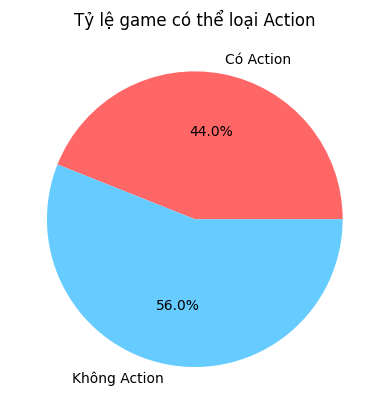

In [10]:
df['has_action'] = df['genres'].str.contains('Action', case=False, na=False)
df['has_indie']  = df['genres'].str.contains('Indie',  case=False, na=False)
df['has_rpg']    = df['genres'].str.contains('RPG',    case=False, na=False)

genre_counts = {
    'Action': df['has_action'].sum(),
    'Indie':  df['has_indie'].sum(),
    'RPG':    df['has_rpg'].sum(),
    'Tổng game': len(df)
}

print("Số lượng game theo một số thể loại chính:")
print(genre_counts)

# Pie chart
labels = ['Có Action', 'Không Action']
sizes = [genre_counts['Action'], len(df) - genre_counts['Action']]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#ff6666', '#66ccff'])
plt.title('Tỷ lệ game có thể loại Action')
plt.show()

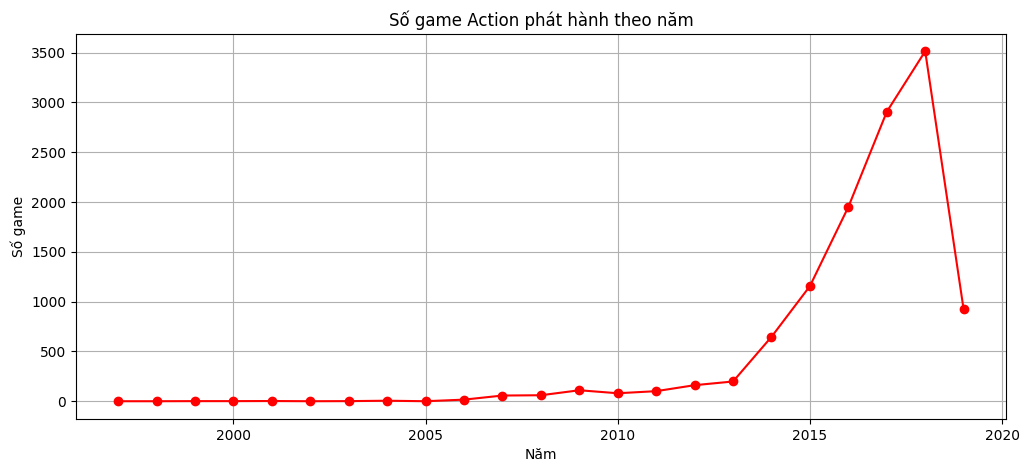

In [11]:
action_by_year = df[df['has_action']].groupby('year').size()
plt.figure(figsize=(12,5))
action_by_year.plot(kind='line', marker='o', color='red')
plt.title('Số game Action phát hành theo năm')
plt.xlabel('Năm')
plt.ylabel('Số game')
plt.grid(True)
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [13]:
X_input = df[['price', 'positive_ratio', 'average_playtime', 'achievements', 'owners_num']].copy()

X_input['log_price'] = np.log1p(X_input['price'])
X_input['log_playtime'] = np.log1p(X_input['average_playtime'])
X_input['log_owners'] = np.log1p(X_input['owners_num'])
X_input['log_achievements'] = np.log1p(X_input['achievements'])

# Loại bỏ cột gốc, chỉ giữ cột log và positive_ratio
features_to_use = ['log_price', 'log_playtime', 'log_owners', 'log_achievements', 'positive_ratio']
final_df = X_input[features_to_use]

# Thêm One-Hot Encoding cho Genres 
popular_genres = ['Action', 'Indie', 'Casual', 'Adventure', 'Strategy', 'RPG', 'Simulation', 'Free to Play']
for genre in popular_genres:
    final_df.loc[:, genre] = df['genres'].str.contains(genre, case=False, na=False).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_df)

# PCA: Giữ lại 95% thông tin
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled) 

print(f"Dữ liệu gốc: {X_scaled.shape} -> Sau PCA: {X_pca.shape}")

C:\Users\asus\AppData\Local\Temp\ipykernel_19164\1183126265.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.loc[:, genre] = df['genres'].str.contains(genre, case=False, na=False).astype(int)
C:\Users\asus\AppData\Local\Temp\ipykernel_19164\1183126265.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.loc[:, genre] = df['genres'].str.contains(genre, case=False, na=False).astype(int)
C:\Users\asus\AppData\Local\Temp\ipykernel_19164\1183126265.py:15: SettingWithCopyWarning: 
A value is

Dữ liệu gốc: (27075, 13) -> Sau PCA: (27075, 12)



K | Inertia (WCSS)    | Silhouette Score
--------------------------------------------------
 2 |         303,830 |            0.1865
 3 |         279,346 |            0.1535
 4 |         251,073 |            0.1551
 5 |         232,986 |            0.1627
 6 |         215,983 |            0.1421
 7 |         205,480 |            0.1416
 8 |         198,005 |            0.1322
 9 |         190,257 |            0.1285
10 |         184,721 |            0.1301
11 |         180,453 |            0.1403


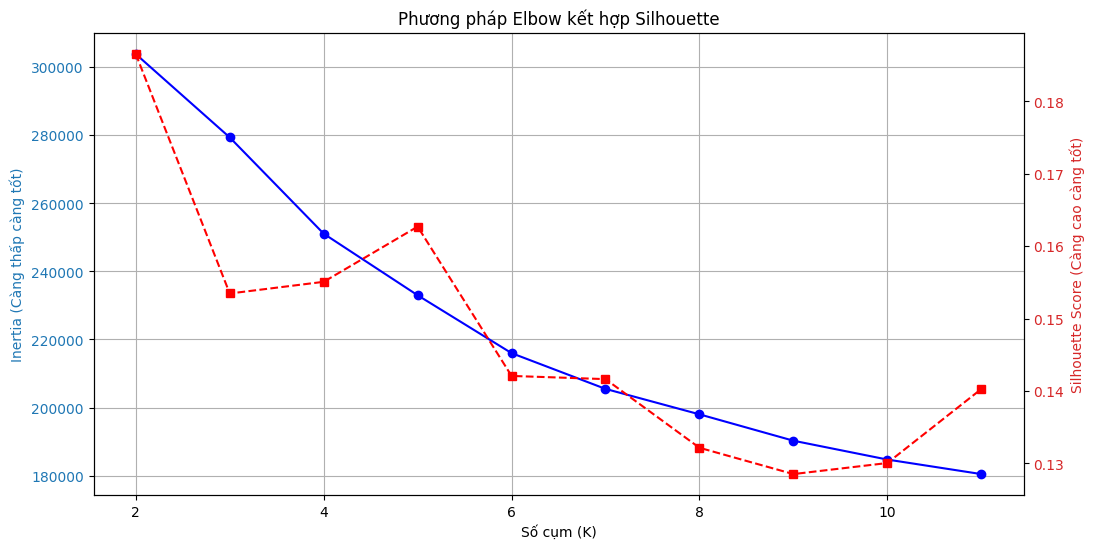

In [14]:
k_range = range(2, 12)
inertias = []
sil_scores = []

print("\nK | Inertia (WCSS)    | Silhouette Score")
print("-" * 50)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca) 
    
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_))
    
    print(f"{k:2d} | {km.inertia_:15,.0f} | {sil_scores[-1]:17.4f}")
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Số cụm (K)')
ax1.set_ylabel('Inertia (Càng thấp càng tốt)', color=color)
ax1.plot(k_range, inertias, 'bo-', label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score (Càng cao càng tốt)', color=color)
ax2.plot(k_range, sil_scores, 'rs--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Phương pháp Elbow kết hợp Silhouette')
plt.show()


<Axes: >

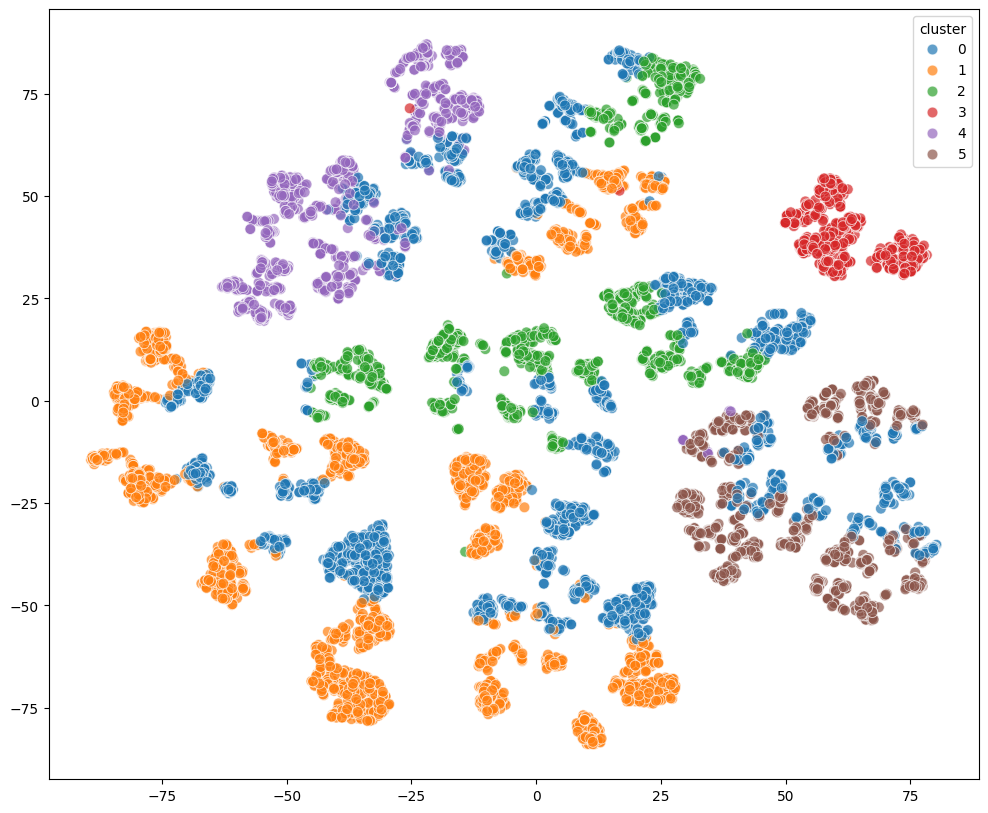

In [15]:
k_best = 6  # Bạn chọn từ biểu đồ trên (thường là điểm khuỷu tay + silhouette cao)

kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X_scaled)



pca = PCA(n_components=10)  # Giảm chiều trước để t-SNE nhanh (tối đa 13 features)

X_pca = pca.fit_transform(X_scaled)



tsne = TSNE(n_components=2, random_state=42, perplexity=40, learning_rate=200)

X_tsne = tsne.fit_transform(X_pca[:10000])  # Lấy 10k mẫu để nhanh



plt.figure(figsize=(12,10))

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['cluster'][:10000],

                palette='tab10', alpha=0.7, s=60)

Tóm tắt đặc điểm từng cụm:


,Giá trung bình,Giá trung vị,Tỷ lệ positive trung bình,Playtime trung bình,Playtime trung vị,Owners trung bình,Số game
cluster,,,,,,,
0,9.19,6.99,0.76,714.40,261.0,541700.29,4114
1,4.59,3.99,0.73,2.96,0.0,14412.97,10485
2,7.80,5.19,0.70,7.09,0.0,26089.42,3713
3,0.10,0.00,0.70,554.44,0.0,592667.25,1704
4,7.23,4.99,0.64,12.38,0.0,18914.64,3819
5,6.74,4.99,0.71,20.85,0.0,22165.12,3240


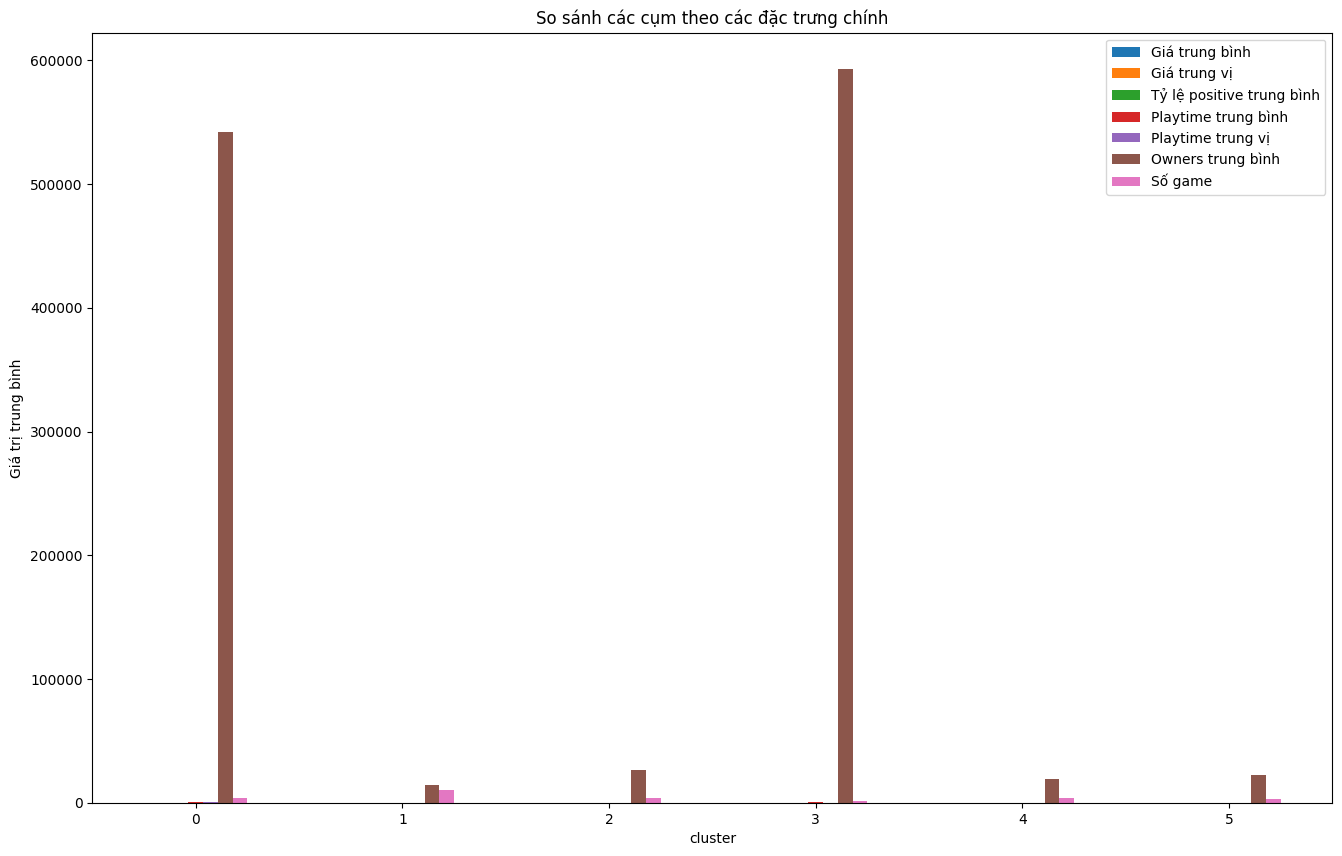

In [16]:
cluster_stats = df.groupby('cluster').agg({
    'price': ['mean', 'median'],
    'positive_ratio': 'mean',
    'average_playtime': ['mean', 'median'],
    'owners_num': 'mean',
    'name': 'count'  # Số game trong cụm
}).round(2)

cluster_stats.columns = ['Giá trung bình', 'Giá trung vị', 'Tỷ lệ positive trung bình',
                         'Playtime trung bình', 'Playtime trung vị', 'Owners trung bình', 'Số game']

print("Tóm tắt đặc điểm từng cụm:")
display(cluster_stats)

cluster_stats.plot(kind='bar', figsize=(16,10))
plt.title('So sánh các cụm theo các đặc trưng chính')
plt.xticks(rotation=0)
plt.ylabel('Giá trị trung bình')
plt.show()

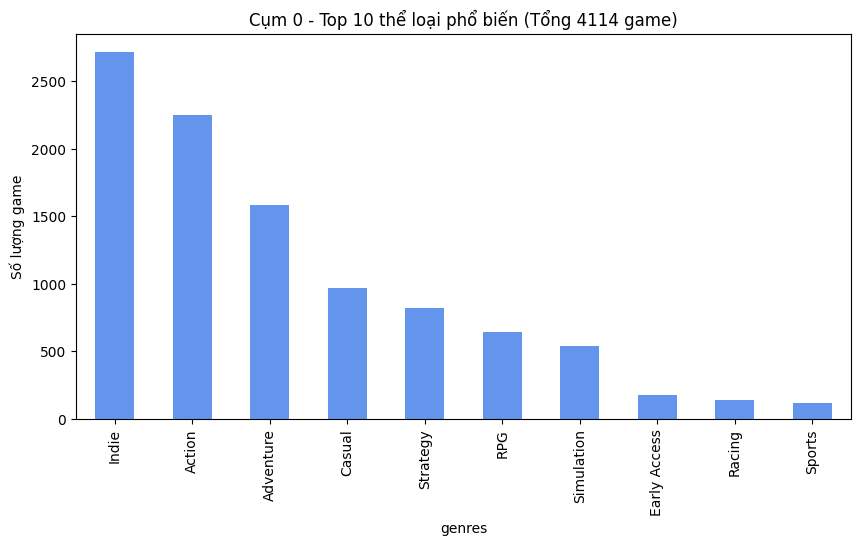

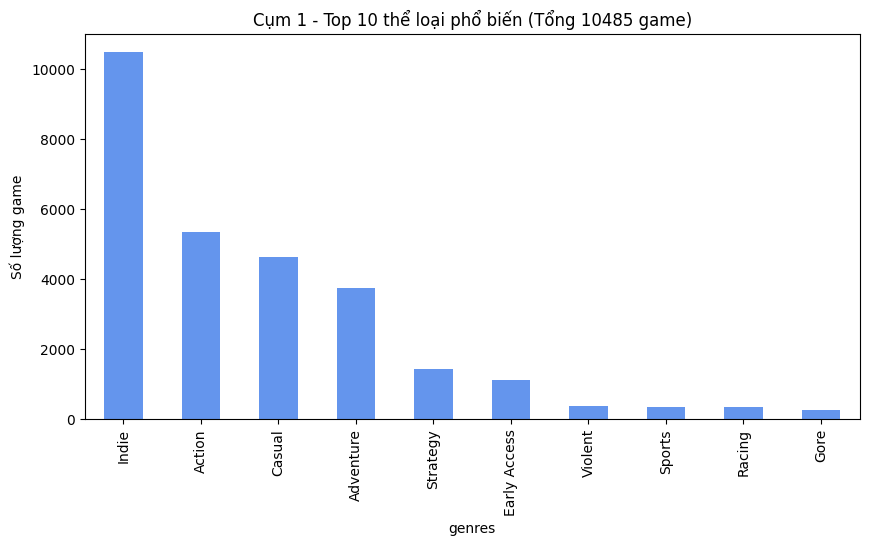

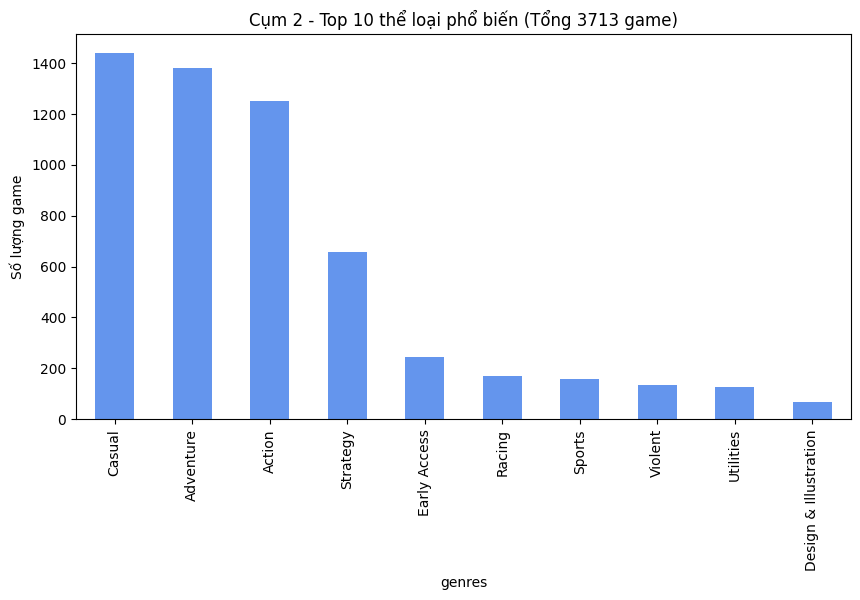

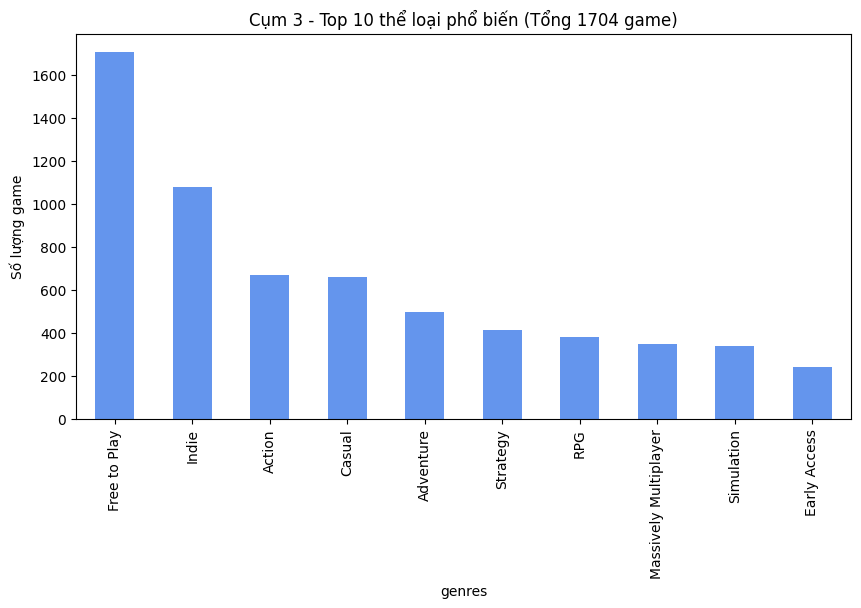

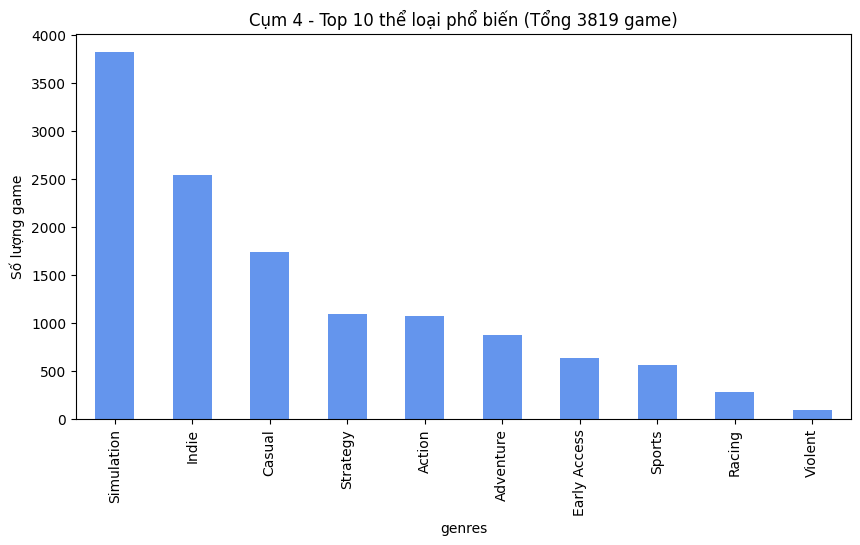

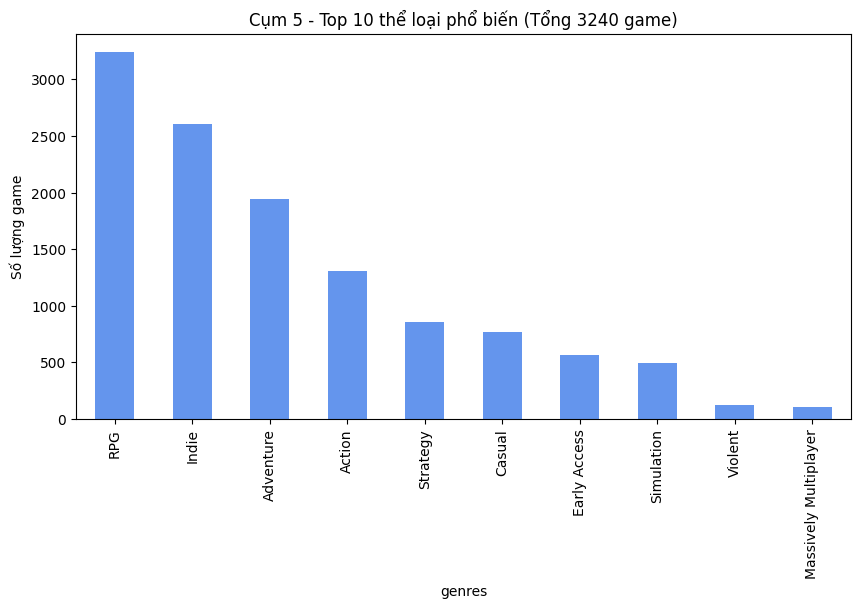

In [17]:
for c in range(k_best):
    cluster_data = df[df['cluster'] == c]
    top_genres = cluster_data['genres'].str.split(';').explode().value_counts().head(10)
    
    plt.figure(figsize=(10,5))
    top_genres.plot(kind='bar', color='cornflowerblue')
    plt.title(f'Cụm {c} - Top 10 thể loại phổ biến (Tổng {len(cluster_data)} game)')
    plt.ylabel('Số lượng game')
    plt.show()

In [18]:
for c in range(k_best):
    print(f"\n=== Cụm {c} - {cluster_stats.iloc[c]['Số game']} game ===")
    top_games = df[df['cluster'] == c][['name', 'genres', 'price', 'positive_ratio', 'average_playtime', 'owners_num']]
    top_games = top_games.sort_values('positive_ratio', ascending=False).head(8)
    display(top_games)


=== Cụm 0 - 4114.0 game ===


,name,genres,price,positive_ratio,average_playtime,owners_num
7900,RefRain - prism memories -,Action;Indie,10.99,1.000000,280,10000
12754,A Long Road Home,Adventure;Casual;Indie,1.69,1.000000,413,35000
6517,Trigonarium,Action;Indie,3.99,1.000000,572,10000
10681,Star Boss,Action;Casual;Indie,0.79,1.000000,272,35000
14205,Chaos Town,Action;Indie;RPG,2.89,1.000000,302,35000
13164,Xenobox VR,Action;Indie;Early Access,3.99,1.000000,182,35000
18404,東方天空璋 ～ Hidden Star in Four Seasons.,Action;Indie,11.39,0.987281,413,75000
6164,Umihara Kawase,Action;Indie,6.99,0.987013,270,10000



=== Cụm 1 - 10485.0 game ===


,name,genres,price,positive_ratio,average_playtime,owners_num
25913,祈風 Inorikaze,Adventure;Casual;Indie,8.29,1.0,75,10000
8548,Champions of Breakfast,Action;Indie,2.09,1.0,0,10000
19998,The Void Rains Upon Her Heart,Action;Indie;Early Access,7.19,1.0,0,10000
9198,Corinne Cross's Dead & Breakfast,Adventure;Indie,3.99,1.0,0,10000
23654,Lonk's Adventure,Adventure;Indie;Early Access,4.99,1.0,0,10000
14729,Youropa,Action;Adventure;Indie,19.49,1.0,0,10000
18632,Dead Dungeon,Action;Adventure;Indie,3.99,1.0,0,10000
25842,GLAD VALAKAS TOWER DEFENCE,Action;Casual;Indie;Strategy,1.69,1.0,0,10000



=== Cụm 2 - 3713.0 game ===


...

,name,genres,price,positive_ratio,average_playtime,owners_num
26773,阿津,Adventure;Free to Play;RPG,0.0,1.0,0,10000
23836,Escape Lala,Adventure;Free to Play;Indie,0.0,1.0,0,10000
24528,GonzoVR,Free to Play;Indie;Early Access,0.0,1.0,0,10000
26816,Prologue for a Vacant Kingdom,Action;Adventure;Free to Play;Indie;RPG,0.0,1.0,0,10000
26721,"Its Simple, SHOOT",Action;Casual;Free to Play,0.0,1.0,0,10000
17710,Morgan lives in a Rocket House in VR,Casual;Free to Play;Indie,0.0,1.0,0,10000
17595,Toran,Adventure;Free to Play;Indie,0.0,1.0,0,10000
13051,SYMMETRY alpha,Free to Play;Design & Illustration,0.0,1.0,0,10000



=== Cụm 4 - 3819.0 game ===


,name,genres,price,positive_ratio,average_playtime,owners_num
23462,Newfound Courage,Adventure;Indie;Simulation,7.19,1.0,0,10000
23352,Lily's Night Off,Adventure;Simulation,2.89,1.0,0,10000
23202,Walk on Arrow,Action;Casual;Indie;Massively Multiplayer;Simu...,8.29,1.0,0,10000
17546,Fart Simulator 2018,Action;Adventure;Casual;Indie;Simulation,1.69,1.0,0,10000
22709,Museum of Symmetry,Adventure;Casual;Indie;Simulation,0.00,1.0,0,10000
13231,Stunt Kite Masters VR,Action;Simulation;Sports,3.99,1.0,0,10000
13399,Super Amazeballs,Action;Adventure;Casual;Indie;Racing;Simulation,3.99,1.0,0,10000
5530,Ruler by Default,Casual;Indie;Simulation,7.19,1.0,0,10000



=== Cụm 5 - 3240.0 game ===


,name,genres,price,positive_ratio,average_playtime,owners_num
26919,ALILIA-亚利利亚的精灵们,Action;Adventure;Indie;RPG,2.89,1.0,0,10000
26498,Blood Memery|血色记忆,Adventure;Indie;RPG,2.09,1.0,0,10000
4840,Notrium,Action;Adventure;Indie;RPG,1.69,1.0,0,10000
20693,Ninjin: Clash of Carrots,Action;Adventure;Indie;RPG,11.99,1.0,0,10000
12169,Thy Sword,Action;Adventure;Indie;RPG,5.99,1.0,0,10000
26543,The Cradle of Ruin/毁灭的摇篮/ほろびのゆりかご,Adventure;RPG;Simulation,2.09,1.0,0,10000
12082,Giants: Citizen Kabuto,Violent;Action;Adventure;RPG,6.99,1.0,0,10000
13997,Stonekeep,Action;Adventure;RPG,6.99,1.0,0,10000
